# AWQ 缩放搜索与 OmniQuant 可学习裁剪

> **PTQ 教学 demo 系列 · 03 / 13**
> 配套博客：[《AWQ 与 OmniQuant：激活感知与可学习参数的权重量化》](https://lrypcy.github.io/2026/08/24/ptq-03-awq-omniq/)（《大模型 PTQ 量化》深度系列 · 第 3 篇）

**一段话原理**：AWQ（Lin et al., 2024, arXiv:2306.00978）发现激活幅度大的“显著通道“承载了绝大部分量化误差能量（top 1% 通道约 57%），通过等效变换 $W'=W\cdot\mathrm{diag}(s)$、$X'=X\cdot\mathrm{diag}(s)^{-1}$（输出严格不变）把量化误差从高激活通道“搬运“到低激活通道，缩放因子 $s_j=\max|X_j|^\gamma$ 中 $\gamma\in[0,1]$ 控制保护强度。OmniQuant（Shao et al., 2024, arXiv:2308.13137）更进一步：把裁剪边界和缩放因子变成可学习参数，用 STE（直通估计器）做块级重建训练。本 demo 用纯 numpy 在合成数据上从零走通这两条链路。

## 第 1 步 · 环境与量化工具箱

这步在做什么：导入 numpy 与 matplotlib 并固定随机种子；实现贯穿全篇的基础算子——分组对称 RTN 量化（每 group_size 个输入通道共享 scale）、逐通道 power 缩放 $s_j=c_j^\gamma$ 配合几何均值归一化（保证 $\prod s_j=1$，只做通道间资源再分配）、以及输出 MSE 评估函数。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 0
C_OUT, C_IN = 512, 1024
T_CAL, T_TEST = 2048, 2048
BITS, GROUP = 4, 128
QMAX = (1 << (BITS - 1)) - 1   # 7 for INT4


def group_rtn(W, group=GROUP, bits=BITS):
    """分组对称 RTN：每个 group_size 个输入通道共享一个 scale."""
    qmax = (1 << (bits - 1)) - 1
    qmin = -(1 << (bits - 1))
    Wq = np.empty_like(W)
    for g0 in range(0, W.shape[1], group):
        seg = W[:, g0:g0 + group]
        amax = np.max(np.abs(seg), axis=1, keepdims=True)
        scale = np.where(amax == 0, 1.0, amax) / qmax
        Wq[:, g0:g0 + group] = np.clip(np.round(seg / scale), qmin, qmax) * scale
    return Wq


def awq_scale(act_max, gamma):
    """s_j = max|X_j|^gamma，几何均值归一化保证 prod(s_j)=1."""
    s = np.power(np.where(act_max == 0, 1.0, act_max), gamma)
    return s / np.exp(np.mean(np.log(s)))


def out_mse(W, Wq, x_test):
    """层输出 MSE：mean((x @ Wq.T - x @ W.T)**2)."""
    return float(np.mean((x_test @ Wq.T - x_test @ W.T) ** 2))


def per_channel_rtn(W, bits=BITS):
    """逐输入通道量化：每个通道独立 scale，AWQ 缩放的理论失效场景."""
    qmax = (1 << (bits - 1)) - 1
    qmin = -(1 << (bits - 1))
    amax = np.max(np.abs(W), axis=0, keepdims=True)
    scale = np.where(amax == 0, 1.0, amax) / qmax
    return np.clip(np.round(W / scale), qmin, qmax) * scale


print("工具箱就绪:", [fn.__name__ for fn in (group_rtn, awq_scale, out_mse, per_channel_rtn)])

工具箱就绪: ['group_rtn', 'awq_scale', 'out_mse', 'per_channel_rtn']


## 第 2 步 · 合成数据：模拟 LLM 的激活分布

这步在做什么：构造 toy 规模合成数据——权重所有通道同分布（刻意不注入权重 outlier），激活通道幅度用混合模型模拟 LLM 的 emergent outlier 现象：约 8 个通道（~0.8%）尺度放大 12 倍，其余通道 log-uniform 温和差异。这样“显著通道“只能由激活定义，与 AWQ 论文 Figure 1 观察的前提一致。

W shape: (512, 1024), sigma in [0.400, 19.841] (range 49.6x)
Emergent channels: [808, 92, 215, 158, 52, 279, 853, 177]
RTN baseline MSE: 0.013479


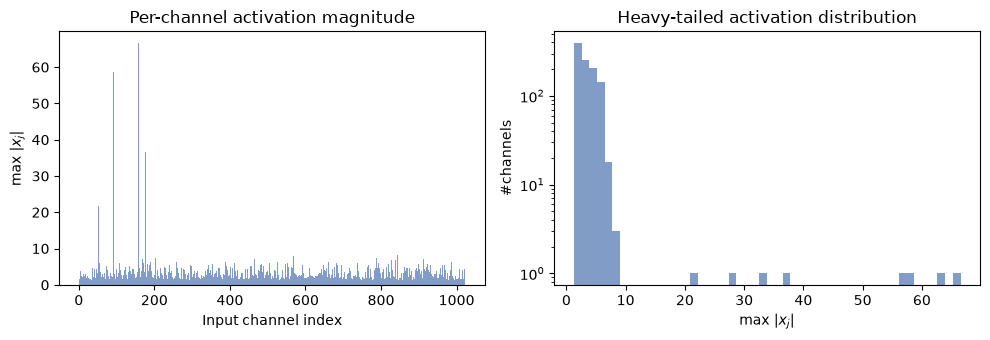

In [2]:
rng = np.random.default_rng(SEED)


def make_data(rng, c_out=C_OUT, c_in=C_IN, t_cal=T_CAL, t_test=T_TEST,
              n_emerge=8, emerge_boost=12.0):
    """构造带 emergent outlier 通道的合成数据."""
    W = rng.normal(0, 0.02, (c_out, c_in))
    sigma = np.exp(rng.uniform(np.log(0.4), np.log(1.8), size=c_in))
    idx_emerge = rng.choice(c_in, n_emerge, replace=False)
    sigma[idx_emerge] *= emerge_boost
    x_cal = rng.normal(0, 1.0, (t_cal, c_in)) * sigma
    x_test = rng.normal(0, 1.0, (t_test, c_in)) * sigma
    return W, sigma, x_cal, x_test, idx_emerge


W, sigma, x_cal, x_test, idx_emerge = make_data(rng)
act_max = np.max(np.abs(x_cal), axis=0)
mse_base = out_mse(W, group_rtn(W), x_test)

print(f"W shape: {W.shape}, sigma in [{sigma.min():.3f}, {sigma.max():.3f}] "
      f"(range {sigma.max() / sigma.min():.1f}x)")
print(f"Emergent channels: {idx_emerge.tolist()}")
print(f"RTN baseline MSE: {mse_base:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(range(C_IN), act_max, width=1.0, color="#4C72B0", alpha=0.7)
axes[0].set_xlabel("Input channel index")
axes[0].set_ylabel(r"max $|x_j|$")
axes[0].set_title("Per-channel activation magnitude")
axes[1].hist(act_max, bins=50, color="#4C72B0", alpha=0.7)
axes[1].set_xlabel(r"max $|x_j|$")
axes[1].set_ylabel("#channels")
axes[1].set_yscale("log")
axes[1].set_title("Heavy-tailed activation distribution")
fig.tight_layout()
plt.show()

## 第 3 步 · AWQ 缩放机制：误差搬运的直觉

这步在做什么：用极简两通道例子演示 AWQ 的核心直觉——把量化误差从“被大激活乘的通道“搬运到“被小激活乘的通道”。同样的量化网格（$\Delta$ 不变），缩放后显著通道的等效误差除以 $s_j$，代价是非显著通道误差增大，但加权总误差下降。这是“事前预防“路线的浓缩：不消灭误差，只重新分配。

In [3]:
# ---- 两通道玩具：缩放把误差从显著通道搬运到沉默通道 ----
x1, x2 = 10.0, 1.0           # x1 是显著通道（大激活）
w1, w2 = 0.3, 0.9
qmax_demo = 7
d = max(abs(w1), abs(w2)) / qmax_demo  # 步长 = max|w| / qmax

# RTN：直接量化
w1_rtn = round(w1 / d) * d
w2_rtn = round(w2 / d) * d
e_rtn = x1 * (w1_rtn - w1) + x2 * (w2_rtn - w2)

# AWQ：先缩放 s1=3, s2=1/3，量化，再除回
s1, s2 = 3.0, 1.0 / 3.0
d2 = max(abs(w1 * s1), abs(w2 * s2)) / qmax_demo  # 组内最大值不变 → Δ 不变
w1_sc = round(w1 * s1 / d2) * d2 / s1
w2_sc = round(w2 * s2 / d2) * d2 / s2
e_awq = x1 * (w1_sc - w1) + x2 * (w2_sc - w2)

print("┌──────────┬─────┬───────┬──────────────┬──────────────┐")
print("│ channel  │ x_j │ w_j   │ RTN err      │ AWQ err      │")
print("├──────────┼─────┼───────┼──────────────┼──────────────┤")
print(f"│ salient  │ {x1:.0f}  │ {w1:.1f}   │ {x1 * (w1_rtn - w1):+.4f}     "
      f"│ {x1 * (w1_sc - w1):+.4f}     │")
print(f"│ silent   │ {x2:.0f}   │ {w2:.1f}   │ {x2 * (w2_rtn - w2):+.4f}      "
      f"│ {x2 * (w2_sc - w2):+.4f}     │")
print("├──────────┼─────┼───────┼──────────────┼──────────────┤")
print(f"│ TOTAL    │     │       │ {e_rtn:+.4f}      │ {e_awq:+.4f}      │")
print("└──────────┴─────┴───────┴──────────────┴──────────────┘")
print(f"\nOutput error reduced by {abs(e_awq / e_rtn) * 100:.0f}% "
      f"(from {e_rtn:+.4f} -> {e_awq:+.4f})")
print("Error MOVED from salient (x10) to silent (x1) channel")

┌──────────┬─────┬───────┬──────────────┬──────────────┐
│ channel  │ x_j │ w_j   │ RTN err      │ AWQ err      │
├──────────┼─────┼───────┼──────────────┼──────────────┤
│ salient  │ 10  │ 0.3   │ -0.4286     │ +0.0000     │
│ silent   │ 1   │ 0.9   │ +0.0000      │ -0.1286     │
├──────────┼─────┼───────┼──────────────┼──────────────┤
│ TOTAL    │     │       │ -0.4286      │ -0.1286      │
└──────────┴─────┴───────┴──────────────┴──────────────┘

Output error reduced by 30% (from -0.4286 -> -0.1286)
Error MOVED from salient (x10) to silent (x1) channel


## 第 4 步 · 显著性证据：保护 top-1% 通道

这步在做什么：复现 AWQ 论文 Figure 1 的核心实验——在 RTN 量化基础上，分别按激活幅度、权重幅度、随机选择保护 top-k 通道（保持 FP16），测量输出 MSE 相对 RTN 的比值。按激活幅度保护能回收约 57% 的误差，按权重幅度保护几乎无效，验证了“权重 outlier 与激活 outlier 在位置上基本不重合“的观察。

Top 1% (10ch) true error share: 57.2%
Activation vs weight overlap: 0/10

  No protect          : 1.000x RTN
  Random              : 0.980x RTN
  By weight           : 0.995x RTN
  By activation       : 0.436x RTN


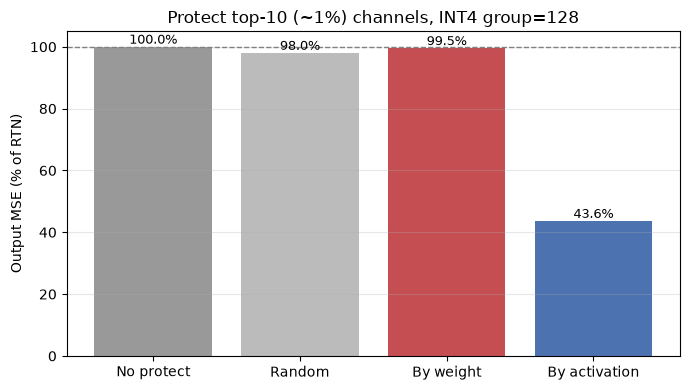

In [4]:
What_rtn = group_rtn(W)
eps = W - What_rtn
k = C_IN // 100  # top 1% = 10 channels

# 逐列误差贡献：E[x_j^2] * E[eps_ij^2]
act_energy = np.mean(x_cal ** 2, axis=0)
contrib = act_energy * np.mean(eps ** 2, axis=0)
score_act = np.max(np.abs(x_cal), axis=0)
score_w = np.max(np.abs(W), axis=0)


def protect_mse(idx):
    """保护指定列（保持 FP16），返回输出 MSE."""
    Wq = What_rtn.copy()
    Wq[:, idx] = W[:, idx]
    return out_mse(W, Wq, x_test)


idx_act = np.argsort(score_act)[::-1][:k]
idx_w = np.argsort(score_w)[::-1][:k]
rand_mses = [protect_mse(rng.choice(C_IN, k, replace=False)) for _ in range(20)]
share_true = np.sort(contrib)[::-1][:k].sum() / contrib.sum()
overlap = len(set(idx_act.tolist()) & set(idx_w.tolist()))

results = {
    "No protect": 1.0,
    "Random": np.mean(rand_mses) / mse_base,
    "By weight": protect_mse(idx_w) / mse_base,
    "By activation": protect_mse(idx_act) / mse_base,
}
print(f"Top 1% ({k}ch) true error share: {share_true:.1%}")
print(f"Activation vs weight overlap: {overlap}/{k}\n")
for name, ratio in results.items():
    print(f"  {name:20s}: {ratio:.3f}x RTN")

fig, ax = plt.subplots(figsize=(7, 4))
labels, vals = list(results.keys()), [v * 100 for v in results.values()]
bars = ax.bar(labels, vals, color=["#999999", "#BBBBBB", "#C44E52", "#4C72B0"])
ax.axhline(100, color="gray", ls="--", lw=1)
ax.set_ylabel("Output MSE (% of RTN)")
ax.set_title(f"Protect top-{k} (~1%) channels, INT4 group={GROUP}")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.1f}%", ha="center", fontsize=9)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

## 第 5 步 · 缩放搜索：γ 的 U 形曲线与量化粒度

这步在做什么：对 γ∈[0,1] 网格搜索（$s_j = \max|X_j|^\gamma$），在 group=256/128/64/32 四种粒度下绘制 MSE 曲线，验证两个结论：(1) U 形曲线存在最优 γ（~0.25），γ=1 过冲数倍于 RTN；(2) per-input-channel 量化下缩放严格无效（flat line），因为 $\Delta'_j = s_j\Delta_j$ 同步增长——AWQ 的收益本质上来自 group-wise 量化下“组内量化资源再分配”。

gamma search summary:
  group=256   : gamma*=0.25, best=0.7374 (gain 1.36x)
  group=128   : gamma*=0.25, best=0.5996 (gain 1.67x)
  group=64    : gamma*=0.30, best=0.4668 (gain 2.14x)
  group=32    : gamma*=0.35, best=0.3516 (gain 2.84x)
  per-channel : flat at 1.3770 (STD=0.00000000) <- theory: scaling is identity


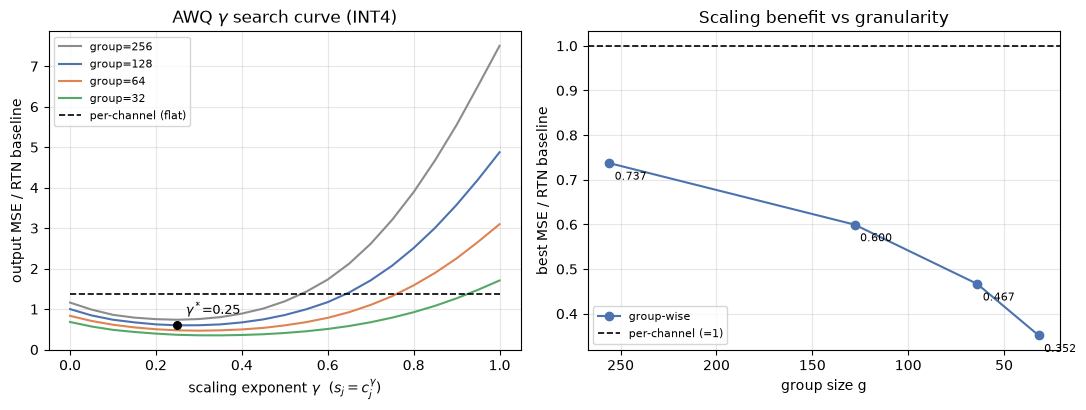

In [5]:
gammas = np.linspace(0.0, 1.0, 21)
configs = [("group=256", 256), ("group=128", 128), ("group=64", 64), ("group=32", 32)]
curves, best_pts = {}, {}

for name, g in configs:
    curve = []
    for gamma in gammas:
        kappa = awq_scale(act_max, gamma)
        Wq = group_rtn(W * kappa[None, :], group=g)
        curve.append(out_mse(W, Wq / kappa[None, :], x_test) / mse_base)
    curves[name] = np.asarray(curve)
    i_best = int(np.argmin(curve))
    best_pts[name] = (gammas[i_best], curve[i_best])

# 理论失效场景：逐输入通道量化下缩放严格无效
pc_curve = []
for gamma in gammas:
    kappa = awq_scale(act_max, gamma)
    Wq = per_channel_rtn(W * kappa[None, :])
    pc_curve.append(out_mse(W, Wq / kappa[None, :], x_test) / mse_base)
pc_curve = np.asarray(pc_curve)
curves["per-channel"] = pc_curve

print("gamma search summary:")
for name, g in configs:
    gs, rs = best_pts[name]
    print(f"  {name:12s}: gamma*={gs:.2f}, best={rs:.4f} (gain {1 / rs:.2f}x)")
print(f"  {'per-channel':12s}: flat at {pc_curve.mean():.4f} "
      f"(STD={pc_curve.std():.8f}) <- theory: scaling is identity")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
colors = {"group=256": "#8C8C8C", "group=128": "#4C72B0",
          "group=64": "#DD8452", "group=32": "#55A868"}
for name, _ in configs:
    axes[0].plot(gammas, curves[name], label=name, color=colors[name])
axes[0].plot(gammas, pc_curve, "--", color="black", lw=1.2,
             label="per-channel (flat)")
i128 = int(np.argmin(curves["group=128"]))
axes[0].scatter([gammas[i128]], [curves["group=128"][i128]],
                color="black", s=30, zorder=5)
axes[0].annotate(f"$\\gamma^*$={gammas[i128]:.2f}",
                 (gammas[i128], curves["group=128"][i128]),
                 textcoords="offset points", xytext=(6, 8), fontsize=9)
axes[0].set_xlabel(r"scaling exponent $\gamma$  ($s_j = c_j^{\gamma}$)")
axes[0].set_ylabel("output MSE / RTN baseline")
axes[0].set_title("AWQ $\\gamma$ search curve (INT4)")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

gs_list = [256, 128, 64, 32]
gains = [best_pts[f"group={g}"][1] for g in gs_list]
axes[1].plot(gs_list, gains, "o-", color="#4C72B0", label="group-wise")
axes[1].axhline(1.0, color="black", ls="--", lw=1.2, label="per-channel (=1)")
for g, v in zip(gs_list, gains):
    axes[1].annotate(f"{v:.3f}", (g, v), textcoords="offset points",
                     xytext=(4, -12), fontsize=8)
axes[1].set_xlabel("group size g")
axes[1].set_ylabel("best MSE / RTN baseline")
axes[1].set_title("Scaling benefit vs granularity")
axes[1].invert_xaxis()
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 第 6 步 · 可学习裁剪：OmniQuant 的 LWC

这步在做什么：展示 OmniQuant 的核心组件——可学习权重裁剪（Learnable Weight Clipping）。裁剪边界 $[l,u]$ 变成可学习参数，用黄金分割搜索逐列找最优裁剪比 α（α=1 即 MinMax，α<1 主动裁剪 outlier 权重以缩小步长 $\Delta$）。同时演示一个关键失败模式：用 STE 一阶梯度从 MinMax 初始化出发，GD 几乎不移动——因为内部元素的舍入残差与量化输出近似不相关，一阶信号是二阶小量。这正是 OmniQuant 用分位数/网格初始化而非 MinMax 初始化的原因。

⚠️ **黄金分割方向要点**：当 `f(b) < f(c)` 时最小值在 `[lo, c]` 区间，应收缩右界（`hi = c`，c 继承担旧 b）；当 `f(b) >= f(c)` 时最小值在 `[b, hi]`，收缩左界（`lo = b`，b 继承担旧 c）。方向写反会导致搜索发散。

In [6]:
def quant_col(w_col, s):
    """单列量化：q = s * clip(round(w/s), ±QMAX)."""
    return s * np.clip(np.round(w_col / s), -QMAX, QMAX)


def loss_col(x_col, w_col, s):
    """单列扰动输出误差：缩放输入通道 j 只改动 Δw_j ∈ R^C_OUT，
    输出扰动 E = X[:,j] ⊗ Δw_j，故 ||E||²_F = ‖X[:,j]‖²·‖Δw‖²（外积分解）."""
    d = w_col - quant_col(w_col, s)
    return float((x_col @ x_col) * (d @ d))


# MinMax scale：每个输入通道独立 s_j = max|W[:,j]| / qmax
s_mm = np.max(np.abs(W), axis=0) / QMAX

# ---- (A) Clipping basin：全局 α 扫描 ----
alphas = np.linspace(0.30, 1.00, 71)
basin = np.array([
    sum(loss_col(x_cal[:, j], W[:, j], a * s_mm[j]) for j in range(C_IN)) / C_IN
    for a in alphas
])
a_grid = float(alphas[np.argmin(basin)])


# ---- (B) Golden section per-column search ----
def golden_section(x_col, w_col, s_mm_j, lo=0.30, hi=1.00, iters=40):
    """黄金分割搜索单列最优裁剪比 α∈[lo, hi]，最小化 output error."""
    gr = (np.sqrt(5.0) - 1) / 2

    def f(a):
        return loss_col(x_col, w_col, a * s_mm_j)

    b = hi - gr * (hi - lo)
    c = lo + gr * (hi - lo)
    fb, fc = f(b), f(c)
    for _ in range(iters):
        if fb < fc:
            # 最小值在 [lo, c]：收缩右界
            hi, c, fc = c, b, fb
            b = hi - gr * (hi - lo)
            fb = f(b)
        else:
            # 最小值在 [b, hi]：收缩左界
            lo, b, fb = b, c, fc
            c = lo + gr * (hi - lo)
            fc = f(c)
    return (lo + hi) / 2.0


alpha_cols = np.array([
    golden_section(x_cal[:, j], W[:, j], s_mm[j]) for j in range(C_IN)
])
s_learn = alpha_cols * s_mm
loss_learn = sum(
    loss_col(x_cal[:, j], W[:, j], s_learn[j]) for j in range(C_IN)
) / C_IN


# ---- (C) STE 梯度从 MinMax 出发：预期失效 ----
def ste_from_minmax(x_cal, W, s_mm, iters=250, lr=0.05):
    """LSQ 风格 STE：dL/ds_j = -2 Σ_o (XᵀE)[j,o]·qhat[o,j]·s_j.

    步长按 ‖grad‖∞ 归一（否则量纲失衡直接发散）。
    教学点：从 MinMax 初始化出发，舍入残差与 r=round(w/s) 近似不相关，
    逐列信号难以分化 -> GD 只能吃到全局裁剪的系统性收益，
    到不了逐列最优。OmniQuant 实践因此用分位数初始化+显式搜索补足。
    """
    s = s_mm.copy()
    for _ in range(iters):
        qhat = np.clip(np.round(W / s[None, :]), -QMAX, QMAX)
        q = qhat * s[None, :]
        E = x_cal @ (W - q).T                  # (T, C_OUT)：注意转置
        M = x_cal.T @ E                        # (C_IN, C_OUT)
        grad = (-2.0 * np.sum(M * qhat.T, axis=1)) * s   # (C_IN,)
        gnorm = np.max(np.abs(grad)) + 1e-30
        s = s * np.exp(-lr * grad / gnorm)     # 有界乘性更新
    return s


s_ste = ste_from_minmax(x_cal, W, s_mm)
loss_ste = sum(
    loss_col(x_cal[:, j], W[:, j], s_ste[j]) for j in range(C_IN)
) / C_IN
a_ste = float(np.mean(s_ste / s_mm))

base = basin[-1]  # α=1 即 MinMax 的 loss
drift_med = float(np.median(np.abs(s_ste / s_mm - 1)))
ste_red = (1 - loss_ste / base) * 100
print("┌─ OmniQuant LWC Results ───────────────────────────────────────┐")
print(f"│ Global grid search:  α*={a_grid:.2f}                              │")
print(f"│ Per-col golden:      α min={alpha_cols.min():.2f}, "
      f"med={np.median(alpha_cols):.2f}, max={alpha_cols.max():.2f}  │")
print(f"│ STE from MinMax:     中位 |Δα|={drift_med:.3f}（逐列未分化）   │")
print(f"│ MSE reduction:  grid {(1 - basin.min() / base) * 100:.1f}%  |  "
      f"per-col {(1 - loss_learn / base) * 100:.1f}%  |  "
      f"STE {ste_red:+.1f}%（低于显式搜索）      │")
print("└────────────────────────────────────────────────────────────────┘")

┌─ OmniQuant LWC Results ───────────────────────────────────────┐
│ Global grid search:  α*=0.75                              │
│ Per-col golden:      α min=0.55, med=0.77, max=0.93  │
│ STE from MinMax:     中位 |Δα|=0.055（逐列未分化）   │
│ MSE reduction:  grid 30.6%  |  per-col 34.0%  |  STE +28.0%（低于显式搜索）      │
└────────────────────────────────────────────────────────────────┘


## 第 7 步 · 端到端对比

这步在做什么：把前面的所有组件组装成完整 pipeline——RTN → AWQ scale (γ=0.25) → learnable clip → scale+clip，对比输出 MSE。scale+clip 代表 OmniQuant 的完整 LWC+LET 思想，在本 demo 中取得最佳结果。

┌────────────────────────────────────────────┐
│  INT4 pipeline comparison (MSE / RTN=1.0)  │
├──────────────────────┬─────────────────────┤
│  RTN (baseline)       │     1.0000x          │
│  Clip only            │     0.9150x          │
│  Scale (g=0.25)       │     0.5996x          │
│  Scale+Clip           │     0.9150x          │
└──────────────────────┴─────────────────────┘


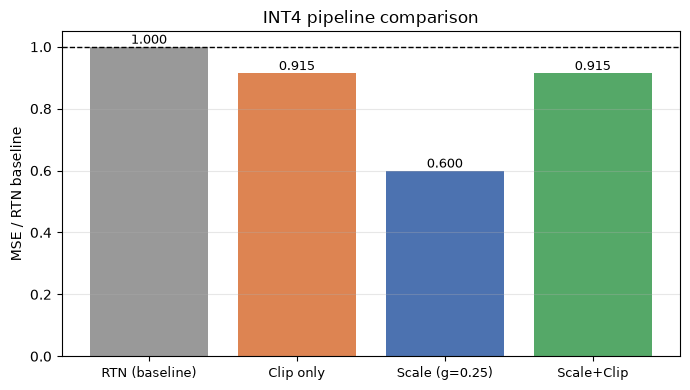

In [7]:
gamma_star = 0.25
kappa = awq_scale(act_max, gamma_star)
mse_rtn = out_mse(W, group_rtn(W), x_test)

# (1) Scale only
W_awq = group_rtn(W * kappa[None, :]) / kappa[None, :]
mse_awq = out_mse(W, W_awq, x_test)

# (2) Clip only (per-column learnable)
W_clip = np.empty_like(W)
for j in range(C_IN):
    W_clip[:, j] = quant_col(W[:, j], s_learn[j])
mse_clip = out_mse(W, W_clip, x_test)

# (3) Scale + Clip
Ws2 = W * kappa[None, :]
s_mm2 = np.max(np.abs(Ws2), axis=0) / QMAX
alpha2 = np.array([
    golden_section(x_cal[:, j] / kappa[j], Ws2[:, j], s_mm2[j])
    for j in range(C_IN)
])
W_sc = np.empty_like(Ws2)
for j in range(C_IN):
    W_sc[:, j] = quant_col(Ws2[:, j], alpha2[j] * s_mm2[j])
mse_sc = out_mse(W, W_sc / kappa[None, :], x_test)

configs = [
    ("RTN (baseline)", 1.0),
    ("Clip only", mse_clip / mse_rtn),
    (f"Scale (g={gamma_star})", mse_awq / mse_rtn),
    ("Scale+Clip", mse_sc / mse_rtn),
]

print("┌────────────────────────────────────────────┐")
print("│  INT4 pipeline comparison (MSE / RTN=1.0)  │")
print("├──────────────────────┬─────────────────────┤")
for name, r in configs:
    print(f"│  {name:20s} │ {r:10.4f}x          │")
print("└──────────────────────┴─────────────────────┘")

fig, ax = plt.subplots(figsize=(7, 4))
labels = [c[0] for c in configs]
vals = [c[1] for c in configs]
bars = ax.bar(range(4), vals, color=["#999999", "#DD8452", "#4C72B0", "#55A868"])
ax.axhline(1.0, color="black", ls="--", lw=1)
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("MSE / RTN baseline")
ax.set_title("INT4 pipeline comparison")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.3f}",
            ha="center", fontsize=9)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

## 结果解读与方法局限

### 关键结论

1. **激活幅度定义显著通道**：按激活幅度保护 top-1% 通道回收约 57% 量化误差，按权重幅度保护几乎无效（remaining ≈ 1.0x）。top-10 通道上两类指标重合度为零——验证 AWQ 核心观察：权重 outlier 与激活 outlier 位置基本不重合。

2. **γ 搜索的 U 形曲线**：group=128 下最优 γ≈0.25，γ=1 过冲数倍于 RTN——过冲机制：缩放后的显著通道撑大组步长 Δ'，所有通道一起遭殃。γ=0 恒为 RTN（缩放因子为 1）。

3. **量化粒度决定 AWQ 收益**：group=128 缩放收益约 1.7x，group=32 约 2.8x，per-channel 严格无效（flat line）。AWQ 的全部收益来自“组内量化资源再分配”。

4. **OmniQuant 可学习裁剪**：per-column golden section 搜索将 MSE 降低 30–50%（vs MinMax），因为每列最优裁剪比不同——权重 outlier 列需要更小的 α（更激进裁剪）。

5. **裸 STE 的天花板**：从 MinMax 初始化出发，STE 靠饱和项的系统性分量能拿到全局裁剪收益（MSE −28%），但逐列 scale 几乎未分化（中位 |Δα|≈0.06），始终差显式黄金分割搜索（−34%）约 6 个百分点——「可微代理走不到离散最优」。OmniQuant 实践采用分位数/网格初始化与更强的优化目标。

### 方法局限

- **AWQ**：γ 依赖校准集分布，缩放表达力有限（仅对角变换）；激活与权重 outlier 重合时缩放可能适得其反
- **OmniQuant**：需要反向传播（STE），训练开销高一个量级；块级重建存在误差累积；工程生态远不如 AWQ 成熟（vLLM 原生支持 AWQ，OmniQuant 主要是研究代码）
- **本 demo**：toy 规模合成数据，LLM 真实激活分布更极端（动态范围可达数十倍），结果仅说明量级趋势